In [2]:
# Importing essential libraries for data analysis and visualization

# pandas: used for loading, cleaning, and analyzing structured data
import pandas as pd

# numpy: provides numerical functions and support for array-based computations
import numpy as np

# seaborn: used for creating attractive statistical plots built on top of matplotlib
import seaborn as sns

# matplotlib.pyplot, plotly.express: provides tools to create plots, charts, and visualizations manually
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter

# scipy: used for statistical testing (chi-square test)
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
# Load dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('customer_journey.csv')

# Confirm that the data has been loaded properly
print("Data loaded successfully!")

# Display the number of rows and columns in the dataset
print("Shape of the dataset (rows, columns):", df.shape)

# Show the list of column names to understand the structure of the data
print("Column names in the dataset:", df.columns.tolist())

Data loaded successfully!
Shape of the dataset (rows, columns): (12719, 10)
Column names in the dataset: ['SessionID', 'UserID', 'Timestamp', 'PageType', 'DeviceType', 'Country', 'ReferralSource', 'TimeOnPage_seconds', 'ItemsInCart', 'Purchased']


In [4]:
# Count of missing (null) values for each column - beautifully formatted output
print("\n" + "="*60)
print("NULL VALUES SUMMARY")
print("="*60)
print(df.isnull().sum())
print("="*60)


NULL VALUES SUMMARY
SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64


In [5]:
# Data types for each column with enhanced formatting
print("\n" + "="*60)
print("DATA TYPES SUMMARY")
print("="*60)
print(df.dtypes)
print("="*60)


DATA TYPES SUMMARY
SessionID               str
UserID                  str
Timestamp               str
PageType                str
DeviceType              str
Country                 str
ReferralSource          str
TimeOnPage_seconds    int64
ItemsInCart           int64
Purchased             int64
dtype: object


In [6]:
# Generate comprehensive summary statistics for numeric columns (mean, std, min, max, quartiles)
print("\n" + "="*60)
print("NUMERIC SUMMARY STATISTICS")
print("="*60)
print(df.describe())
print("="*60)


NUMERIC SUMMARY STATISTICS
       TimeOnPage_seconds   ItemsInCart     Purchased
count        12719.000000  12719.000000  12719.000000
mean            97.427707      1.138533      0.397044
std             48.120729      1.689954      0.489304
min             15.000000      0.000000      0.000000
25%             56.000000      0.000000      0.000000
50%             98.000000      0.000000      0.000000
75%            139.000000      2.000000      1.000000
max            180.000000      5.000000      1.000000


In [7]:
#Verify duplicate rows in the dataset and display the count of duplicates
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [8]:
#count SessionID to each UserID 
dfSessionCount = df.groupby(['UserID', 'SessionID']).agg({'SessionID': 'count'}).rename(columns={'SessionID': 'SessionCount'}).reset_index().sort_values('SessionCount', ascending=False)
dfSessionCount.head(10)

,UserID,SessionID,SessionCount
4990,user_2999,session_3395,5
4993,user_3000,session_2530,5
4994,user_3000,session_3659,5
4995,user_3000,session_4719,5
4997,user_3001,session_2121,5
6,user_1005,session_3889,5
3963,user_2594,session_3985,5
3965,user_2595,session_1680,5
27,user_1010,session_1007,5
37,user_1014,session_4849,5


In [9]:
dfcount = dfSessionCount['SessionCount'].value_counts()
dfsum = dfSessionCount['SessionCount'].value_counts().sum()
dfcount / dfsum * 100

SessionCount
2    47.76
1    20.26
5    20.20
3     9.52
4     2.26
Name: count, dtype: float64

In [16]:
pd.DataFrame({'TotalCount': dfcount, 'Percent (%)': dfcount / dfsum * 100}).reset_index().sort_values('TotalCount', ascending=False)

,SessionCount,TotalCount,Percent (%)
0,2,2388,47.76
1,1,1013,20.26
2,5,1010,20.20
3,3,476,9.52
4,4,113,2.26


Text(0.5, 1.0, 'Distribution of Session Counts per User')

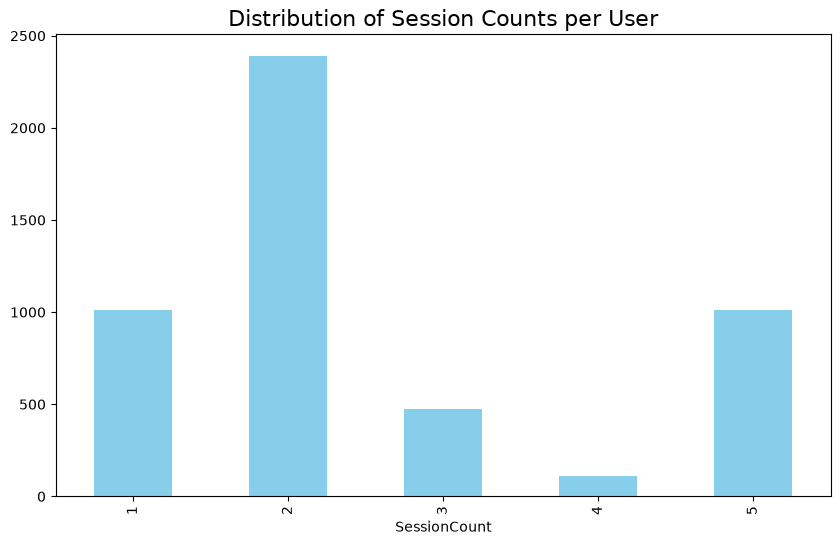

In [11]:

dfcount.sort_index().plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Distribution of Session Counts per User', fontsize=16)

In [12]:
# Funnel Logic Validation
# Check: did sessions actually follow the funnel order, or did some skip steps?

funnel_steps = ['home', 'product_page', 'cart', 'checkout', 'confirmation']
funnel_order = {step: i for i, step in enumerate(funnel_steps)}

# For each session, find all funnel steps visited
session_steps = (
    df[df['PageType'].isin(funnel_steps)]
    .groupby('SessionID')['PageType']
    .apply(set)
    .reset_index()
)

session_steps

,SessionID,PageType
0,session_0,{home}
1,session_1,"{product_page, home}"
2,session_10,"{product_page, home}"
3,session_100,"{product_page, home}"
4,session_1000,"{confirmation, product_page, cart, home, check..."
...,...,...
4995,session_995,"{product_page, home}"
4996,session_996,"{product_page, home}"
4997,session_997,"{confirmation, product_page, cart, home, check..."
4998,session_998,"{product_page, home}"
